#Data Loading

Making the dataset

In [1]:
import sklearn
from sklearn.datasets import make_circles

In [2]:
n_samples = 1000
X, y = make_circles(n_samples, noise=0.03, random_state=42)

In [3]:
len(X), len(y)

(1000, 1000)

In [4]:
print(f"First five of X: \n{X[:5]}")

First five of X: 
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]


In [5]:
print(f"First five of y: {y[:5]}")

First five of y: [1 1 1 1 0]


In [6]:
import pandas as pd
circles = pd.DataFrame({"X1":X[:,0], "X2":X[:,1], "label":y})

In [7]:
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


In [8]:
circles.label.value_counts()

,count
label,
1,500
0,500


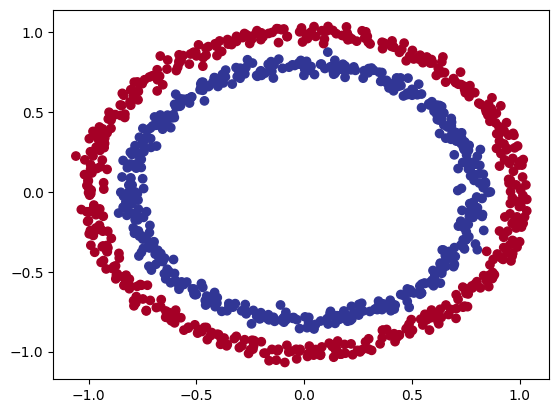

In [9]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],y=X[:,1],c=y,cmap=plt.cm.RdYlBu)

Checking input and output shapes

In [10]:
X.shape, y.shape

((1000, 2), (1000,))

Turning data into tensors and creating train/test splits

In [11]:
import torch
X = torch.from_numpy(X).type(torch.float)

In [12]:
y = torch.from_numpy(y).type(torch.float)

In [13]:
X.dtype

torch.float32

In [14]:
y.dtype

torch.float32

In [15]:
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

Splitting the dataset into training and testing sets

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
len(X_train), len(y_train)

(800, 800)

##Building a Model

To classify a blue or red dot

In [19]:
from torch import nn

In [20]:
from sklearn import datasets

In [21]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5,out_features=1)

  def forward(self, x):
    return self.layer_2(self.layer_1(x))


model_0 = CircleModelV0()
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

Another way to create the same model

In [22]:
model_0 = nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
)

Making some predictions with the model

In [23]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.3288, -0.1067],
                      [-0.3701,  0.6077],
                      [ 0.4315, -0.4756],
                      [ 0.6404, -0.1009],
                      [-0.4002, -0.2786]])),
             ('0.bias', tensor([ 0.1307, -0.6920,  0.7024,  0.3202, -0.0483])),
             ('1.weight',
              tensor([[-0.2426, -0.1049,  0.0478, -0.3049, -0.2302]])),
             ('1.bias', tensor([0.1614]))])

In [24]:
with torch.inference_mode():
  untrained_preds = model_0(X_test)
print(f"Length of predictions: {len(untrained_preds)}, Shape; {untrained_preds.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 labels:\n{y_test[:10]}")

Length of predictions: 200, Shape; torch.Size([200, 1])

First 10 predictions:
tensor([[0.1592],
        [0.1828],
        [0.1131],
        [0.1722],
        [0.1384],
        [0.1526],
        [0.1991],
        [0.1921],
        [0.1121],
        [0.1847]])

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


##Setting up a loss function and an optimser

In [25]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [26]:
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc

##Building a training loop

Going from raw logits->predicted probabilities->predicted labels

In [27]:
with torch.inference_mode():
  y_logits = model_0(X_test[:5])
y_logits

tensor([[0.1592],
        [0.1828],
        [0.1131],
        [0.1722],
        [0.1384]])

In [28]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [29]:
#Using the sgimoid activation function on our logits
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5397],
        [0.5456],
        [0.5283],
        [0.5429],
        [0.5345]])

In [30]:
y_preds = torch.round(y_pred_probs)

Building a training and testing loop

In [31]:
torch.manual_seed(42)
epochs = 100
for epoch in range(epochs):
  model_0.train()
  #Forward Pass
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))
  #Calculate loss/accuracy
  loss = loss_fn(y_logits,y_train) #w/LogitsLoss accepts raw logits as input
  acc = accuracy_fn(y_true=y_train,y_pred=y_pred)
  #Optimizer zero grad
  optimizer.zero_grad()
  #Loss Backward (Backpropagation)
  loss.backward()
  #Optimizer Step (Gradient Descent)
  optimizer.step()
  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test,y_pred=test_pred)
    if epoch%10==0:
      print(f"Epoch:{epoch}| Loss: {loss:.5f} & Acc: {acc:.2f}| Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}")



Epoch:0| Loss: 0.69577 & Acc: 50.00| Test Loss: 0.69697, Test Acc: 50.00
Epoch:10| Loss: 0.69381 & Acc: 50.00| Test Loss: 0.69556, Test Acc: 50.00
Epoch:20| Loss: 0.69328 & Acc: 54.87| Test Loss: 0.69522, Test Acc: 50.00
Epoch:30| Loss: 0.69313 & Acc: 52.50| Test Loss: 0.69514, Test Acc: 48.50
Epoch:40| Loss: 0.69307 & Acc: 52.00| Test Loss: 0.69511, Test Acc: 48.50
Epoch:50| Loss: 0.69305 & Acc: 51.50| Test Loss: 0.69509, Test Acc: 49.50
Epoch:60| Loss: 0.69304 & Acc: 51.88| Test Loss: 0.69508, Test Acc: 47.50
Epoch:70| Loss: 0.69303 & Acc: 51.62| Test Loss: 0.69506, Test Acc: 47.50
Epoch:80| Loss: 0.69302 & Acc: 51.25| Test Loss: 0.69504, Test Acc: 46.50
Epoch:90| Loss: 0.69302 & Acc: 51.25| Test Loss: 0.69502, Test Acc: 46.50


It looks like our model is not learning anything. Only making guesses.

We now make some predictions and make them visual.

In [32]:
import requests
from pathlib import Path
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

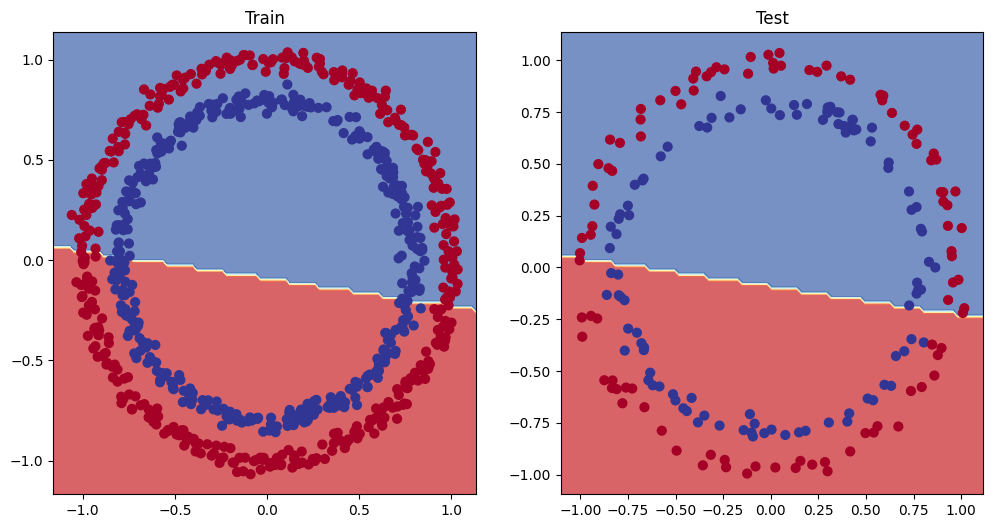

In [33]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

##Improving Our Model

In [34]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.3332, -0.1024],
                      [-0.3713,  0.6089],
                      [ 0.4317, -0.4757],
                      [ 0.6348, -0.0956],
                      [-0.4043, -0.2748]])),
             ('0.bias', tensor([ 0.1489, -0.6860,  0.7006,  0.3432, -0.0316])),
             ('1.weight',
              tensor([[-0.2569, -0.0714,  0.0123, -0.3161, -0.2298]])),
             ('1.bias', tensor([0.0884]))])

#Trying to improve the model
- Adding more hidden units
- Increasing the number of layers
- Increasing the number of epochs

In [35]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2,out_features=10)
    self.layer_2 = nn.Linear(in_features=10,out_features=10)
    self.layer_3 = nn.Linear(in_features=10,out_features=1)

  def forward(self, x):
    z = self.layer_1(x)
    z = self.layer_2(z)
    z = self.layer_3(z)
    return z

model_1 = CircleModelV1()
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [36]:
torch.manual_seed(42)
epochs = 1000
for epoch in range(epochs):
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_train))
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test,y_pred=test_pred)
    if epoch%100==0:
      print(f"Epoch:{epoch}| Loss: {loss:.5f} & Acc: {acc:.2f}| Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}")

Epoch:0| Loss: 0.69396 & Acc: 100.00| Test Loss: 0.69261, Test Acc: 51.00
Epoch:100| Loss: 0.69305 & Acc: 100.00| Test Loss: 0.69379, Test Acc: 48.00
Epoch:200| Loss: 0.69299 & Acc: 100.00| Test Loss: 0.69437, Test Acc: 46.00
Epoch:300| Loss: 0.69298 & Acc: 100.00| Test Loss: 0.69458, Test Acc: 45.00
Epoch:400| Loss: 0.69298 & Acc: 100.00| Test Loss: 0.69465, Test Acc: 46.00
Epoch:500| Loss: 0.69298 & Acc: 100.00| Test Loss: 0.69467, Test Acc: 46.00
Epoch:600| Loss: 0.69298 & Acc: 100.00| Test Loss: 0.69468, Test Acc: 46.00
Epoch:700| Loss: 0.69298 & Acc: 100.00| Test Loss: 0.69468, Test Acc: 46.00
Epoch:800| Loss: 0.69298 & Acc: 100.00| Test Loss: 0.69468, Test Acc: 46.00
Epoch:900| Loss: 0.69298 & Acc: 100.00| Test Loss: 0.69468, Test Acc: 46.00


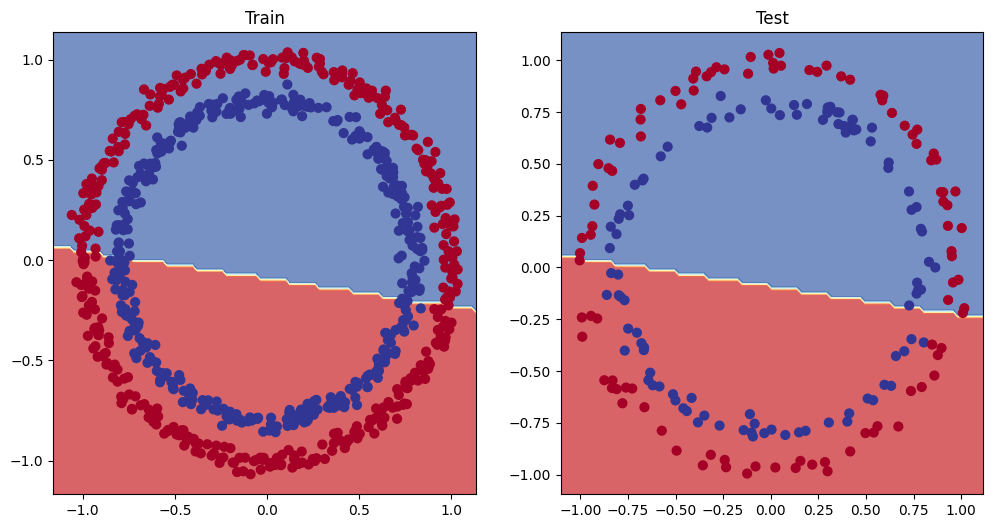

In [37]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

Linearity is not the solution to this problem. It must be non linearity.

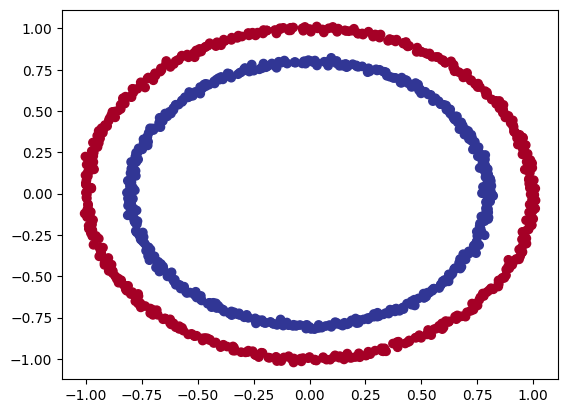

In [38]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000
X, y = make_circles(n_samples, noise=0.01, random_state=42)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)

In [39]:
import torch
from sklearn.model_selection import train_test_split

In [40]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
X_train[:5], y_train[:5]

(tensor([[ 0.6387, -0.4846],
         [ 0.6609, -0.7366],
         [-0.9953, -0.1415],
         [-0.9719, -0.2247],
         [-0.1686,  0.7877]]),
 tensor([1., 0., 0., 0., 1.]))

Building a model with non-linearity

In [42]:
from torch import nn
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10,out_features=10)
    self.layer_3 = nn.Linear(in_features=10,out_features=1)
    self.relu = nn.ReLU() #non-linear activation function

  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_2 = CircleModelV2()
model_2


CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [43]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)

Training a model with non linearity

In [44]:
torch.manual_seed(42)
epochs = 1000
for epoch in range(epochs):
  model_2.train()
  y_logits = model_2(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))
  loss = loss_fn(y_logits, y_train) #input, target
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  model_2.eval()
  with torch.inference_mode():
    test_logits = model_2(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

  if epoch%100==0:
    print(f"Epoch:{epoch}| Loss: {loss:.5f} & Acc: {acc:.2f}| Test Loss: {test_loss:.5f} & Test Acc: {test_acc:.2f}")


Epoch:0| Loss: 0.69295 & Acc: 50.00| Test Loss: 0.69307 & Test Acc: 50.00
Epoch:100| Loss: 0.69117 & Acc: 53.12| Test Loss: 0.69081 & Test Acc: 53.00
Epoch:200| Loss: 0.68983 & Acc: 52.88| Test Loss: 0.68907 & Test Acc: 55.50
Epoch:300| Loss: 0.68803 & Acc: 53.00| Test Loss: 0.68674 & Test Acc: 56.50
Epoch:400| Loss: 0.68521 & Acc: 53.12| Test Loss: 0.68336 & Test Acc: 56.50
Epoch:500| Loss: 0.68117 & Acc: 53.00| Test Loss: 0.67822 & Test Acc: 56.50
Epoch:600| Loss: 0.67532 & Acc: 53.62| Test Loss: 0.67110 & Test Acc: 57.50
Epoch:700| Loss: 0.66659 & Acc: 57.63| Test Loss: 0.66043 & Test Acc: 61.00
Epoch:800| Loss: 0.65164 & Acc: 63.88| Test Loss: 0.64386 & Test Acc: 69.50
Epoch:900| Loss: 0.62356 & Acc: 74.12| Test Loss: 0.61609 & Test Acc: 78.00


Vizualizing the Model

In [45]:
model_2.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_2(X_test))).squeeze()
y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

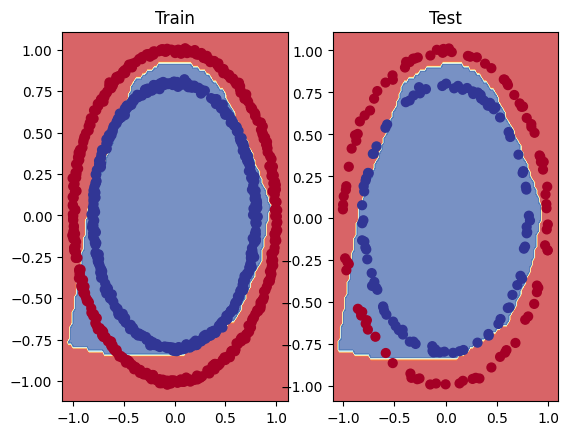

In [46]:
plt.figure()
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_2, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_2,X_test, y_test)

##Improving the Model
Doing this by adding more features/neurons to each layer

In [47]:
from torch import nn
class CircleModelV3(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=15)
    self.layer_2 = nn.Linear(in_features=15,out_features=15)
    self.layer_3 = nn.Linear(in_features=15,out_features=1)
    self.relu = nn.ReLU() #non-linear activation function

  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV3()
model_3


CircleModelV3(
  (layer_1): Linear(in_features=2, out_features=15, bias=True)
  (layer_2): Linear(in_features=15, out_features=15, bias=True)
  (layer_3): Linear(in_features=15, out_features=1, bias=True)
  (relu): ReLU()
)

In [48]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_3.parameters(),
                            lr=0.1)

In [49]:

epochs = 1000
for epoch in range(epochs):
  model_3.train()
  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))
  loss = loss_fn(y_logits, y_train) #input, target
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

  if epoch%100==0:
    print(f"Epoch:{epoch}| Loss: {loss:.5f} & Acc: {acc:.2f}| Test Loss: {test_loss:.5f} & Test Acc: {test_acc:.2f}")


Epoch:0| Loss: 0.69389 & Acc: 45.25| Test Loss: 0.69482 & Test Acc: 44.00
Epoch:100| Loss: 0.68948 & Acc: 56.88| Test Loss: 0.69102 & Test Acc: 54.00
Epoch:200| Loss: 0.68549 & Acc: 65.25| Test Loss: 0.68771 & Test Acc: 60.50
Epoch:300| Loss: 0.68032 & Acc: 65.75| Test Loss: 0.68342 & Test Acc: 61.50
Epoch:400| Loss: 0.67246 & Acc: 62.62| Test Loss: 0.67677 & Test Acc: 58.50
Epoch:500| Loss: 0.65924 & Acc: 64.12| Test Loss: 0.66488 & Test Acc: 62.00
Epoch:600| Loss: 0.63654 & Acc: 76.88| Test Loss: 0.64385 & Test Acc: 75.50
Epoch:700| Loss: 0.59466 & Acc: 96.38| Test Loss: 0.60420 & Test Acc: 95.00
Epoch:800| Loss: 0.51891 & Acc: 99.50| Test Loss: 0.53199 & Test Acc: 99.00
Epoch:900| Loss: 0.39566 & Acc: 99.12| Test Loss: 0.41512 & Test Acc: 98.50


In [50]:
model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

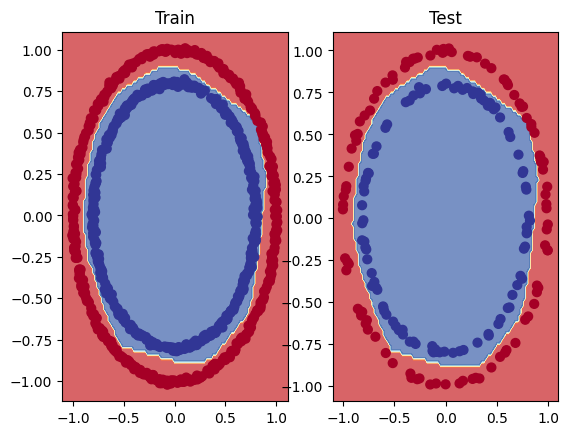

In [51]:
plt.figure()
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3,X_test, y_test)

The model was improved.

##Replicating a Non Linear Activation Function

Just for educational purposes.


In [52]:
A = torch.arange(-10,10,1,dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

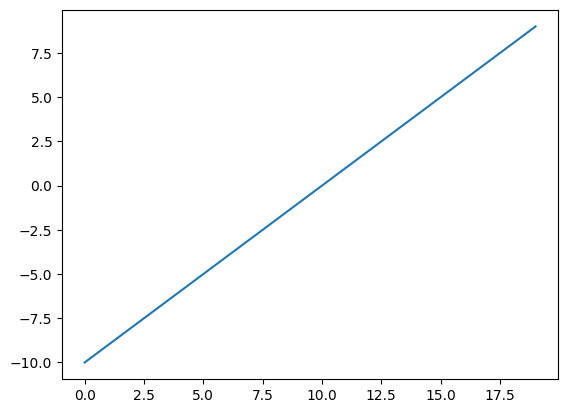

In [53]:
plt.plot(A)
plt.show()

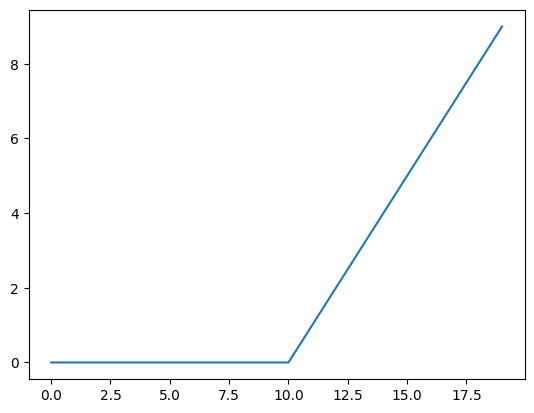

In [54]:
plt.plot(torch.relu(A))

In [55]:
def relu(x: torch.Tensor)-> torch.Tensor:
  return torch.maximum(torch.tensor(0),x)

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

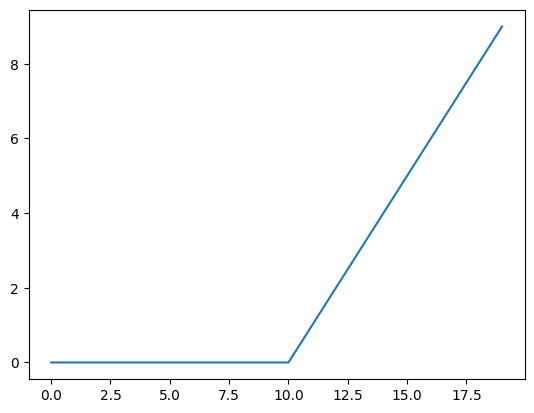

In [56]:
plt.plot(relu(A))

In [57]:
def sigmoid(x):
  return 1/(1+torch.exp(-x))

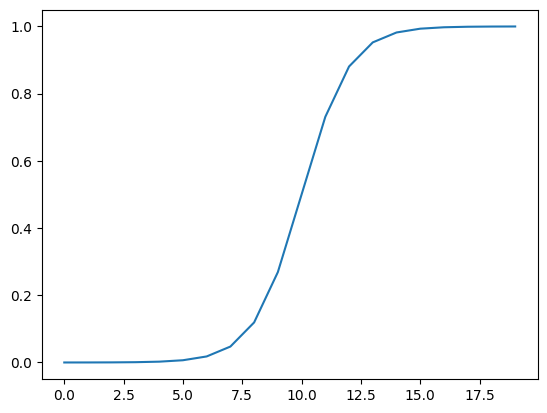

In [58]:
plt.plot(torch.sigmoid(A))

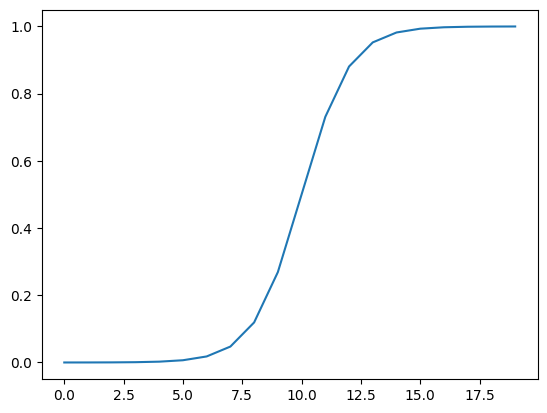

In [59]:
plt.plot(sigmoid(A))

##Multiclass Classification

In [60]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

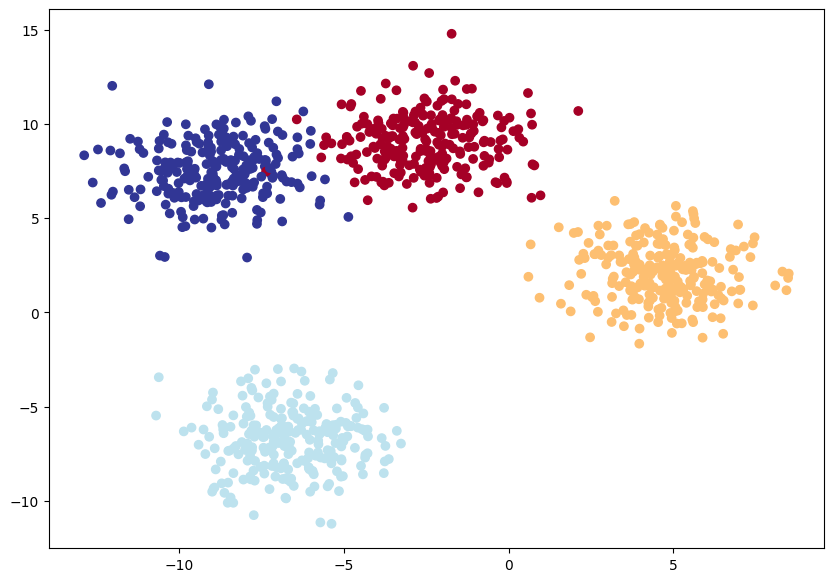

In [61]:
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5,
                            random_state=RANDOM_SEED)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0],X_blob[:,1],c=y_blob,cmap=plt.cm.RdYlBu)

In [62]:
X[:5], y[:5]

(tensor([[ 0.7663,  0.2163],
         [-0.7783,  0.1378],
         [-0.8009,  0.1246],
         [-0.3583,  0.7135],
         [ 0.4388, -0.8985]]),
 tensor([1., 1., 1., 1., 0.]))

Building a muticlass classification model

In [63]:
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features)
    )

  def forward(self, x):
    return self.linear_layer_stack(x)


model_4 = BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8)

In [64]:
X_blob_train.shape, y_blob_train.shape

(torch.Size([800, 2]), torch.Size([800]))

Setting up a loss function and optimizer

In [65]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_4.parameters(),
                            lr=0.1)

In [66]:
with torch.inference_mode():
  y_logits = model_4(X_blob_test)

y_logits[:10] #these are simply logits(4 per sample). They should be converted to prediction probabilities and then to prediction labels, for training and testing

tensor([[-0.0468,  0.2506, -0.2855,  0.2750],
        [-0.0683,  0.0191, -0.2685,  0.0245],
        [ 0.1314, -0.0392, -0.4890, -0.2234],
        [ 0.1382,  0.1313, -0.1232,  0.0536],
        [-0.2421, -0.0092, -0.4731,  0.1881],
        [-0.0889,  0.0186, -0.2891,  0.0039],
        [ 0.1455, -0.0360, -0.5085, -0.2610],
        [-0.1863, -0.0012, -0.4054,  0.1323],
        [ 0.0815, -0.0983, -0.5052, -0.0840],
        [-0.2007, -0.0043, -0.4249,  0.1493]])

In [67]:
y_blob_test[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0])

Converting the model's logit ouputs to prediction probabilities and then to prediction labels

In [68]:
y_pred_probs = torch.softmax(y_logits,dim=1)
y_pred_probs[:5]

tensor([[0.2216, 0.2983, 0.1745, 0.3057],
        [0.2496, 0.2723, 0.2043, 0.2738],
        [0.3244, 0.2736, 0.1745, 0.2275],
        [0.2716, 0.2697, 0.2091, 0.2496],
        [0.2177, 0.2748, 0.1728, 0.3347]])

In [69]:
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds

tensor([3, 3, 0, 0, 3, 1, 0, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 0, 1, 3, 3, 3, 0, 0,
        0, 0, 1, 3, 3, 3, 3, 1, 1, 3, 1, 0, 0, 3, 3, 0, 3, 3, 1, 0, 3, 3, 3, 3,
        3, 3, 1, 3, 3, 0, 3, 0, 1, 1, 1, 0, 0, 3, 3, 0, 0, 3, 3, 3, 3, 3, 3, 3,
        1, 1, 0, 1, 3, 3, 3, 0, 3, 0, 3, 0, 1, 1, 0, 3, 3, 0, 1, 3, 1, 3, 3, 3,
        1, 3, 1, 0, 3, 3, 3, 3, 0, 1, 0, 3, 3, 0, 0, 1, 3, 0, 0, 3, 3, 3, 1, 3,
        0, 3, 3, 1, 0, 3, 3, 3, 0, 3, 1, 0, 3, 0, 3, 1, 3, 3, 1, 1, 1, 3, 0, 0,
        0, 0, 3, 1, 3, 3, 0, 1, 3, 0, 3, 3, 3, 1, 0, 3, 0, 3, 1, 0, 3, 3, 0, 3,
        0, 0, 0, 3, 3, 1, 1, 1, 0, 1, 3, 1, 3, 0, 0, 1, 0, 0, 3, 3, 0, 0, 3, 3,
        1, 1, 0, 3, 3, 1, 0, 1])

Creating a training and testing loop for our model

In [70]:
y_logits.dtype, y_blob_train.dtype

(torch.float32, torch.int64)

In [71]:
torch.manual_seed(42)
epochs = 100
for epoch in range(epochs):
  model_4.train()
  y_logits = model_4(X_blob_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
  loss = loss_fn(y_logits,y_blob_train) #input, target
  acc = accuracy_fn(y_true=y_blob_train,
                    y_pred=y_pred)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_4.eval()
  with torch.inference_mode():
    test_logits = model_4(X_blob_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
    test_loss = loss_fn(test_logits, y_blob_test)
    test_acc = accuracy_fn(y_true=y_blob_test, y_pred=test_pred)

  if epoch%10==0:
    print(f"Epochs :{epoch} | Loss: {loss:.2f} & Acc: {acc:.2f} | Test Loss: {test_loss:.2f} | Test Acc: {test_acc:.2f}")

Epochs :0 | Loss: 1.44 & Acc: 31.50 | Test Loss: 1.37 | Test Acc: 39.50
Epochs :10 | Loss: 0.93 & Acc: 65.25 | Test Loss: 0.90 | Test Acc: 64.50
Epochs :20 | Loss: 0.55 & Acc: 75.88 | Test Loss: 0.56 | Test Acc: 95.00
Epochs :30 | Loss: 0.40 & Acc: 98.62 | Test Loss: 0.41 | Test Acc: 99.00
Epochs :40 | Loss: 0.33 & Acc: 98.62 | Test Loss: 0.34 | Test Acc: 99.00
Epochs :50 | Loss: 0.28 & Acc: 98.75 | Test Loss: 0.29 | Test Acc: 99.50
Epochs :60 | Loss: 0.24 & Acc: 98.75 | Test Loss: 0.25 | Test Acc: 99.50
Epochs :70 | Loss: 0.21 & Acc: 98.75 | Test Loss: 0.22 | Test Acc: 99.50
Epochs :80 | Loss: 0.19 & Acc: 98.75 | Test Loss: 0.20 | Test Acc: 99.50
Epochs :90 | Loss: 0.17 & Acc: 99.00 | Test Loss: 0.18 | Test Acc: 99.50


Evaluating our model through visualization

In [72]:
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test)
  y_pred_probs = torch.softmax(y_logits, dim=1)
  y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:10], y_blob_test[:10]

(tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0]),
 tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0]))

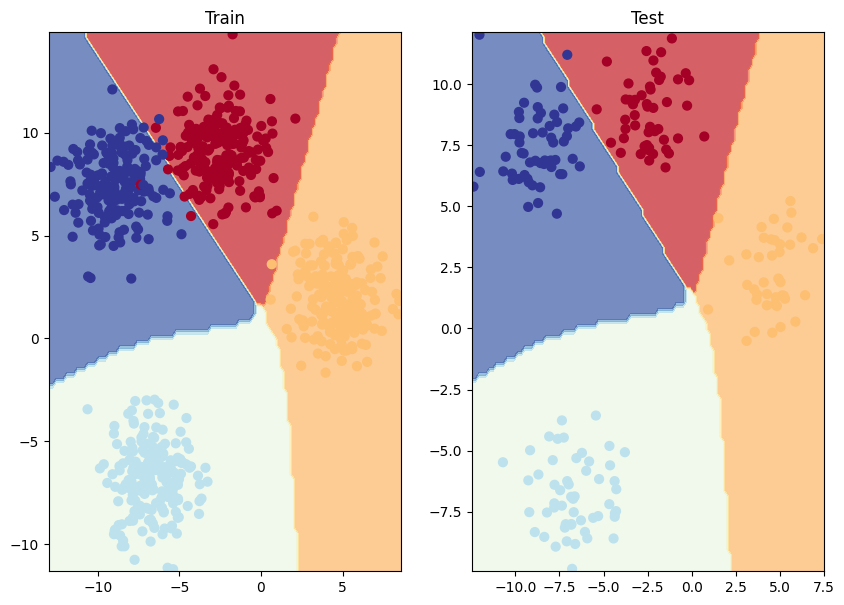

In [73]:
plt.figure(figsize=(10,7))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)